# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RohanNK86/ML_Intern_Assets/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [38]:
import seaborn as sb
import matplotlib.pyplot as pt
import pandas as pd
df = pd.read_csv('/content/content_refresh_anonymized (1).csv')

In [20]:
df

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,impression_tier,position_tier,trend_direction,trend_pct,staleness_score,ctr_gap_score,volume_score,score,reason_code,action
0,content_f6fdf87348f6,client_4ec9599fc2,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,low,page_3_5,down,-100.0,1.000000,0.499102,0.000000,0.649730,REVIEW,Refresh Content
1,content_55a5b1c46474,client_4ec9599fc2,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,low,page_1,down,-88.5,1.000000,0.499102,0.000000,0.649730,REVIEW,Refresh Content
2,content_8d56efff1e71,client_4ec9599fc2,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,low,page_3_5,new,NaN,0.997312,0.499102,0.000000,0.648386,REVIEW,Refresh Content
3,content_1b4ec72dafd4,client_4ec9599fc2,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,low,page_1,down,-100.0,0.997312,0.499102,0.000000,0.648386,REVIEW,Refresh Content
4,content_7a888d3d99c8,client_19581e27de,90.0,0.46,MEDIUM,0.72,keyword article,transactional,NaN,NaN,...,low,deep,down,-100.0,0.838710,0.502695,0.001216,0.570407,REVIEW,Refresh Content
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_0934cd438dd6,client_25fc0e7096,0.0,NaN,NaN,NaN,feedly article,NaN,3217.0,21281.0,...,low,top_3,new,NaN,0.018817,NaN,NaN,NaN,REVIEW,Refresh Content
29996,content_a3af3b8346d8,client_25fc0e7096,0.0,NaN,NaN,NaN,feedly article,NaN,4384.0,30449.0,...,low,top_3,new,NaN,0.013441,NaN,NaN,NaN,REVIEW,Refresh Content
29997,content_92a5d2709aa9,client_25fc0e7096,0.0,NaN,NaN,NaN,feedly article,NaN,4677.0,31391.0,...,low,top_3,new,NaN,0.018817,NaN,NaN,NaN,REVIEW,Refresh Content
29998,content_4be930227848,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,730.0,5475.0,...,low,page_1,stable,0.0,0.051075,NaN,NaN,NaN,REVIEW,Refresh Content


In [26]:
# List of numerical columns you want to impute with mean
num_cols = [
    'search_volume', 'competition', 'cpc',
    'word_count', 'char_count', 'trend_pct',
    'ctr_gap_score', 'volume_score', 'score'
]

# Impute missing values with the column mean using Pandas .mean()
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# For categorical columns like 'competition_level', fill missing values with the mode (most frequent value)
df['competition_level'] = df['competition_level'].fillna(df['competition_level'].mode()[0])

In [27]:
df

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,impression_tier,position_tier,trend_direction,trend_pct,staleness_score,ctr_gap_score,volume_score,score,reason_code,action
0,content_f6fdf87348f6,client_4ec9599fc2,0.0,0.000000,LOW,0.000000,keyword article,informational,3107.760325,20665.277835,...,low,page_3_5,down,-100.000000,1.000000,0.499102,0.000000,0.649730,REVIEW,Refresh Content
1,content_55a5b1c46474,client_4ec9599fc2,0.0,0.000000,LOW,0.000000,keyword article,informational,3107.760325,20665.277835,...,low,page_1,down,-88.500000,1.000000,0.499102,0.000000,0.649730,REVIEW,Refresh Content
2,content_8d56efff1e71,client_4ec9599fc2,0.0,0.000000,LOW,0.000000,keyword article,informational,3107.760325,20665.277835,...,low,page_3_5,new,-4.785969,0.997312,0.499102,0.000000,0.648386,REVIEW,Refresh Content
3,content_1b4ec72dafd4,client_4ec9599fc2,0.0,0.000000,LOW,0.000000,keyword article,informational,3107.760325,20665.277835,...,low,page_1,down,-100.000000,0.997312,0.499102,0.000000,0.648386,REVIEW,Refresh Content
4,content_7a888d3d99c8,client_19581e27de,90.0,0.460000,MEDIUM,0.720000,keyword article,transactional,3107.760325,20665.277835,...,low,deep,down,-100.000000,0.838710,0.502695,0.001216,0.570407,REVIEW,Refresh Content
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_0934cd438dd6,client_25fc0e7096,0.0,0.146954,LOW,0.485342,feedly article,NaN,3217.000000,21281.000000,...,low,top_3,new,-4.785969,0.018817,0.499922,0.002147,0.212339,REVIEW,Refresh Content
29996,content_a3af3b8346d8,client_25fc0e7096,0.0,0.146954,LOW,0.485342,feedly article,NaN,4384.000000,30449.000000,...,low,top_3,new,-4.785969,0.013441,0.499922,0.002147,0.212339,REVIEW,Refresh Content
29997,content_92a5d2709aa9,client_25fc0e7096,0.0,0.146954,LOW,0.485342,feedly article,NaN,4677.000000,31391.000000,...,low,top_3,new,-4.785969,0.018817,0.499922,0.002147,0.212339,REVIEW,Refresh Content
29998,content_4be930227848,client_d4735e3a26,0.0,0.146954,LOW,0.485342,feedly article,NaN,730.000000,5475.000000,...,low,page_1,stable,0.000000,0.051075,0.499922,0.002147,0.212339,REVIEW,Refresh Content


In [28]:
from sklearn.model_selection import train_test_split

In [33]:
X = df[['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'trend_pct', 'staleness_score', 'ctr_gap_score', 'volume_score']]
y = df['score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [36]:
pred = lm.predict(X_test)

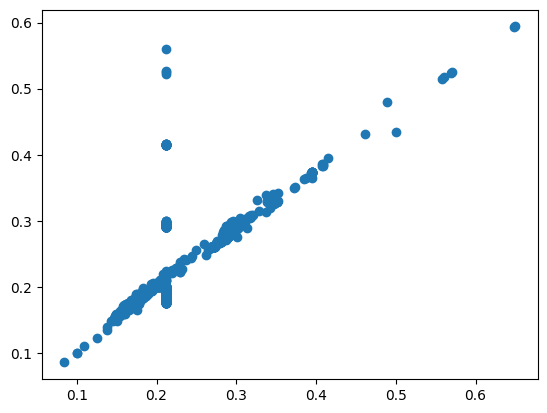

In [39]:
pt.scatter(y_test, pred)
pt.show()

In [40]:
from sklearn import metrics

In [42]:
print('MAE : ',metrics.mean_absolute_error(y_test, pred))
print('MSE : ',metrics.mean_squared_error(y_test, pred))
print('RMSE : ',metrics.root_mean_squared_error(y_test, pred))

MAE :  0.008212338611579741
MSE :  0.0002937892856394233
RMSE :  0.017140282542578558


In [44]:
cdf = pd.DataFrame(lm.coef_, X_train.columns, columns=['Coefficient'])
cdf

,Coefficient
search_volume,-1.003399e-04
competition,7.920353e-04
cpc,-6.080156e-05
word_count,2.596499e-06
char_count,-3.938296e-08
trend_pct,-3.199850e-07
staleness_score,4.368627e-01
ctr_gap_score,3.199414e-01
volume_score,7.626910e+00


In [47]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,impression_tier,position_tier,trend_direction,trend_pct,staleness_score,ctr_gap_score,volume_score,score,reason_code,action
0,content_f6fdf87348f6,client_4ec9599fc2,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,low,page_3_5,down,-100.0,1.000000,0.499102,0.000000,0.649730,REVIEW,Refresh Content
1,content_55a5b1c46474,client_4ec9599fc2,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,low,page_1,down,-88.5,1.000000,0.499102,0.000000,0.649730,REVIEW,Refresh Content
2,content_8d56efff1e71,client_4ec9599fc2,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,low,page_3_5,new,NaN,0.997312,0.499102,0.000000,0.648386,REVIEW,Refresh Content
3,content_1b4ec72dafd4,client_4ec9599fc2,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,low,page_1,down,-100.0,0.997312,0.499102,0.000000,0.648386,REVIEW,Refresh Content
4,content_7a888d3d99c8,client_19581e27de,90.0,0.46,MEDIUM,0.72,keyword article,transactional,NaN,NaN,...,low,deep,down,-100.0,0.838710,0.502695,0.001216,0.570407,REVIEW,Refresh Content


In [54]:
# 1. Grab 5 sample rows from the test set
sample_X = X_test.head(5)
sample_y_actual = y_test.head(5)

# 2. Predict scores using your model
sample_preds = lm.predict(sample_X)

# 3. Combine into a comparison table
comparison_df = pd.DataFrame({
    'Actual Score': sample_y_actual.values,
    'Predicted Score': sample_preds,
    'Difference (Error)': sample_y_actual.values - sample_preds
})

comparison_df

,Actual Score,Predicted Score,Difference (Error)
0,0.287917,0.277963,0.009954
1,0.212339,0.182883,0.029456
2,0.178010,0.181967,-0.003956
3,0.174295,0.178464,-0.004169
4,0.176545,0.180586,-0.004041


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.